# Ejercicio 2: modelo de Volterra-Lotka modificado

*(Traducción a Python de `ejercicio2.m` + `volterra.m`, usando `sympy`, `numpy`, `scipy` y `matplotlib`)*

El modelo de Volterra-Lotka se puede escribir como:

$$\dot x_1 = x_1-x_1x_2-\mu x_1^2, \qquad \dot x_2 = x_1x_2-x_2-\tau x_2\dot x_1$$

Encontrar los puntos de equilibrio, linealizar en torno a aquel cuyas dos variables de estado son distintas de cero, y mostrar cómo la estabilidad/inestabilidad de dicho punto depende de $\mu$ y $\tau$. Discutir la posibilidad de existencia de un ciclo límite.

**Nota sobre organización del código:** igual que en ejercicios anteriores, `volterra.m` es un archivo de función aparte en MATLAB; aquí la definimos como una función normal, dentro del propio notebook, antes de usarla.

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Puntos de equilibrio y linealización (simbólico, con $\mu,\tau$ genéricos)

In [2]:
x1, x2, s, mu, tau = sp.symbols('x1 x2 s mu tau', real=True)

f = sp.Matrix([
    x1 - x1*x2 - mu*x1**2,
    x1*x2 - x2 - tau*x2*(x1 - x1*x2 - mu*x1**2)
])
f

⎡                 2                        ⎤
⎢           - μ⋅x₁  - x₁⋅x₂ + x₁           ⎥
⎢                                          ⎥
⎢       ⎛      2             ⎞             ⎥
⎣- τ⋅x₂⋅⎝- μ⋅x₁  - x₁⋅x₂ + x₁⎠ + x₁⋅x₂ - x₂⎦

In [3]:
J = f.jacobian([x1, x2])
J

⎡      -2⋅μ⋅x₁ - x₂ + 1                             -x₁                    ⎤
⎢                                                                          ⎥
⎢                                           ⎛      2             ⎞         ⎥
⎣-τ⋅x₂⋅(-2⋅μ⋅x₁ - x₂ + 1) + x₂  τ⋅x₁⋅x₂ - τ⋅⎝- μ⋅x₁  - x₁⋅x₂ + x₁⎠ + x₁ - 1⎦

In [4]:
soluciones = sp.solve(f, [x1, x2], dict=True)
soluciones

Hay tres puntos de equilibrio: el origen $(0,0)$, uno con $x_2=0$ (población de presas sola, sin depredador), y el que nos interesa especialmente — $(1,\,1-\mu)$ — donde ambas poblaciones coexisten.

In [5]:
for punto in soluciones:
    print('Punto de equilibrio:', punto)

    Je = J.subs(punto)
    E = Je.eigenvals()
    print('autovalores:', E)

    D = (s*sp.eye(2) - Je).det()
    D = sp.collect(sp.expand(D), s)
    print('polinomio caracteristico:', D)
    print()

Punto de equilibrio: {x1: 0, x2: 0}
autovalores: {1: 1, -1: 1}
polinomio caracteristico: s**2 - 1

Punto de equilibrio: {x1: 1, x2: 1 - mu}
autovalores: {-mu*tau/2 - mu/2 + tau/2 - sqrt(mu**2*tau**2 + 2*mu**2*tau + mu**2 - 2*mu*tau**2 - 2*mu*tau + 4*mu + tau**2 - 4)/2: 1, -mu*tau/2 - mu/2 + tau/2 + sqrt(mu**2*tau**2 + 2*mu**2*tau + mu**2 - 2*mu*tau**2 - 2*mu*tau + 4*mu + tau**2 - 4)/2: 1}
polinomio caracteristico: -mu + s**2 + s*(mu*tau + mu - tau) + 1

Punto de equilibrio: {x1: 1/mu, x2: 0}
autovalores: {-(mu - 1)/mu: 1, -1: 1}
polinomio caracteristico: s**2 + s*(2 - 1/mu) + 1 - 1/mu



Para el punto de coexistencia $(1,\,1-\mu)$, la naturaleza de la estabilidad (parte real de los autovalores positiva, negativa, o nula con parte imaginaria no nula — posible ciclo límite vía bifurcación de Hopf) depende de la combinación concreta de $\mu$ y $\tau$, tal y como pide el enunciado.

### Exploración opcional: mapa de estabilidad en función de $\mu,\tau$

El `.m` original deja comentado un bloque que barre una malla de valores de $\mu$ y $\tau$, sustituye numéricamente en la expresión simbólica de los autovalores, y representa la parte real resultante como una superficie 3D (para ver visualmente dónde cambia de signo, es decir, dónde está el umbral de estabilidad). Lo dejamos aquí también como comentario/referencia, sin ejecutar, porque sustituir simbólicamente en una malla grande de puntos es *muy* lento comparado con evaluar una función numérica normal — si quieres explorarlo, es más rápido convertir antes la expresión simbólica de los autovalores a una función numérica con `sp.lambdify` y evaluarla sobre la malla con `numpy`, en vez de sustituir símbolo a símbolo con `sympy`:

```python
# punto de coexistencia
punto_coexistencia = soluciones[1]   # {x1: 1, x2: 1 - mu}
Je_coex = J.subs(punto_coexistencia)
autoval_expr = list(Je_coex.eigenvals().keys())

# convertimos las expresiones simbolicas a funciones numericas rapidas
E1_func = sp.lambdify((mu, tau), autoval_expr[0], 'numpy')
E2_func = sp.lambdify((mu, tau), autoval_expr[1], 'numpy')

MU = np.arange(0, 5.001, 0.25)
TAU = np.arange(0, 5.001, 0.25)
MUM, TAUM = np.meshgrid(MU, TAU)

Er1 = np.real(E1_func(MUM, TAUM))
Er2 = np.real(E2_func(MUM, TAUM))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(TAUM, MUM, Er1, alpha=0.6)
ax.plot_surface(TAUM, MUM, Er2, alpha=0.6)
```

Fuera de los valores de estabilidad, el sistema da problemas numéricos y hay que manejar `solve_ivp` con cautela, o el tiempo de integración se vuelve terriblemente largo — el mismo aviso que ya daba el `.m` original para `ode45`.

## Función de estado (equivalente a `volterra.m`)

In [6]:
def volterra(t, x, mu, tau):
    """Ecuaciones de estado del modelo de Volterra-Lotka modificado."""
    x1, x2 = x
    dx1 = x1 - x1*x2 - mu*x1**2
    dx2 = x1*x2 - x2 - tau*x2*(x1 - x1*x2 - mu*x1**2)
    return [dx1, dx2]

## Caso 1: $\mu=0.5,\ \tau=0.5$ (estable y convergente)

**Nota:** a partir de aquí reutilizamos los nombres `mu` y `tau` como valores numéricos normales (`float`), tal y como hace el `.m` original — dejan de ser los símbolos de `sympy` usados arriba. Es una práctica habitual tanto en MATLAB como en Python (reusar un nombre de variable para otro propósito distinto más adelante en el mismo script), aunque conviene tenerlo presente para no confundirse si se ejecutan las celdas en otro orden.

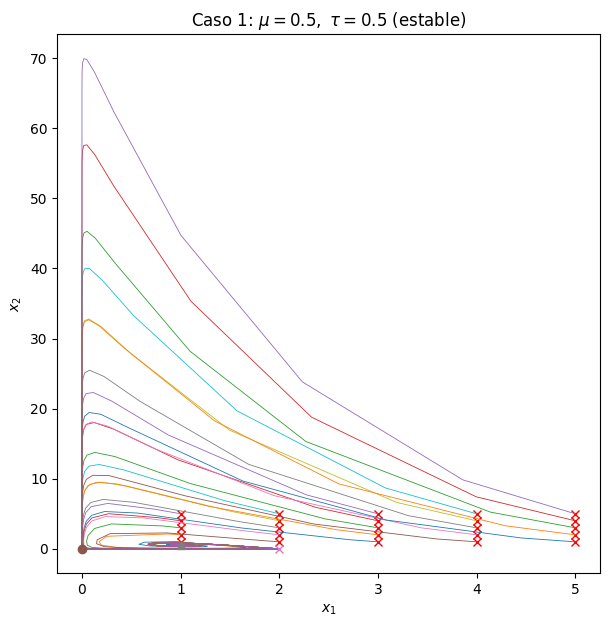

In [7]:
mu = 0.5
tau = 0.5

fig, ax = plt.subplots(figsize=(7, 7))

for i in range(1, 6):
    for j in range(1, 6):
        sol = solve_ivp(volterra, [0, 1000], [i, j], args=(mu, tau), max_step=1)
        ax.plot(i, j, 'xr')
        ax.plot(sol.y[0], sol.y[1], linewidth=0.6)

ax.plot(0, 0, 'o')
ax.plot(1/mu, 0, 'x')
ax.plot(1, 1 - mu, '^')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(r'Caso 1: $\mu=0.5,\ \tau=0.5$ (estable)')
plt.show()

Todas las trayectorias convergen al punto de coexistencia $(1,\,1-\mu) = (1,\,0.5)$.

## Caso 2: $\mu=0,\ \tau=0$ (Volterra puro)

Volvemos al modelo de Volterra-Lotka original (sin los términos de amortiguamiento $\mu,\tau$), que se sabe que da lugar a órbitas periódicas cerradas (no a convergencia a un punto fijo). Usamos una tolerancia más estricta, equivalente a `odeset('Reltol',1e-9,'MaxStep',1e-1)`.

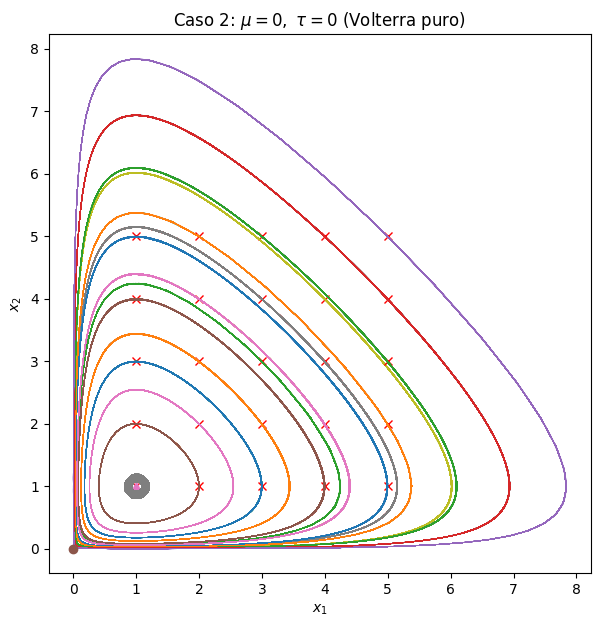

In [8]:
mu = 0.0
tau = 0.0

fig, ax = plt.subplots(figsize=(7, 7))

for i in range(1, 6):
    for j in range(1, 6):
        sol = solve_ivp(volterra, [0, 1000], [i, j], args=(mu, tau),
                         rtol=1e-9, max_step=0.1)
        ax.plot(i, j, 'xr')
        ax.plot(sol.y[0], sol.y[1], linewidth=0.6)

ax.plot(0, 0, 'o')
# ojo: 1/mu no esta definido para mu=0, se omite ese punto (division por cero)
ax.plot(1, 1 - mu, '^')

sol_extra = solve_ivp(volterra, [0, 1000], [1.1, 1.1], args=(mu, tau),
                       rtol=1e-9, max_step=0.1)
ax.plot(sol_extra.y[0], sol_extra.y[1], '+')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(r'Caso 2: $\mu=0,\ \tau=0$ (Volterra puro)')
plt.show()

**Nota importante — diferencia real con MATLAB:** en el `.m` original, esta sección incluye `plot(1/mu,0,'x')` con $\mu=0$. En MATLAB, `1/0` da `Inf` silenciosamente (sin error), así que ese punto simplemente no aparece dentro de los límites visibles del gráfico. **En Python puro, `1/mu` con `mu = 0.0` (un `float` nativo) SÍ lanza `ZeroDivisionError`** — a diferencia de MATLAB, y a diferencia también de `numpy` (`1/np.array(0.0)` sí da `inf`, con un aviso, sin excepción). Puedes comprobarlo tú mismo en la siguiente celda. Por eso, directamente omití esa línea en este caso, en vez de intentar reproducir el `Inf` silencioso de MATLAB.

In [9]:
try:
    print(1 / mu)
except ZeroDivisionError as e:
    print('ZeroDivisionError:', e, ' -> a diferencia de MATLAB, aqui SI hay excepcion')

ZeroDivisionError: float division by zero  -> a diferencia de MATLAB, aqui SI hay excepcion


Las trayectorias no convergen a ningún punto: oscilan periódicamente alrededor del punto de coexistencia, como es característico del modelo de Volterra-Lotka clásico (autovalores puramente imaginarios: un centro).

## Caso 3: $\mu=0.1,\ \tau=0.2$ (ciclo límite)

Pintamos solo un caso desde dentro y otro desde fuera del ciclo límite.

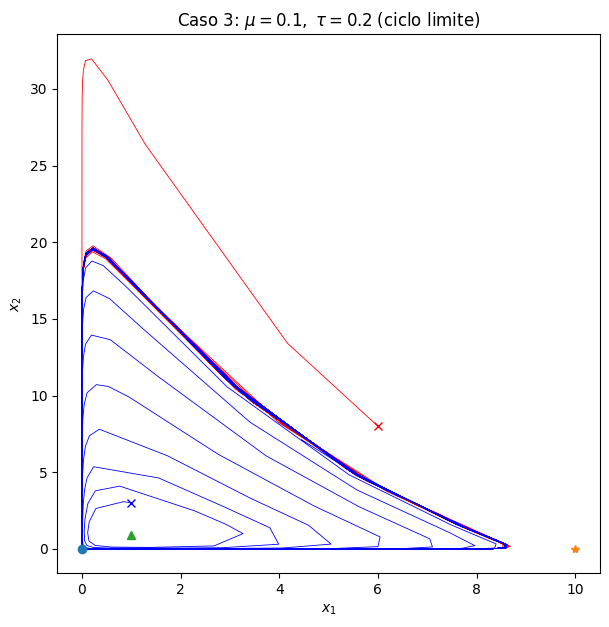

In [10]:
mu = 0.1
tau = 0.2

fig, ax = plt.subplots(figsize=(7, 7))

x0 = [6, 8]
sol = solve_ivp(volterra, [0, 1000], x0, args=(mu, tau), max_step=1)
ax.plot(x0[0], x0[1], 'xr')
ax.plot(sol.y[0], sol.y[1], 'r', linewidth=0.6)

x0 = [1, 3]
sol = solve_ivp(volterra, [0, 1000], x0, args=(mu, tau), max_step=1)
ax.plot(x0[0], x0[1], 'xb')
ax.plot(sol.y[0], sol.y[1], 'b', linewidth=0.6)

ax.plot(0, 0, 'o')
ax.plot(1/mu, 0, '*')
ax.plot(1, 1 - mu, '^')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(r'Caso 3: $\mu=0.1,\ \tau=0.2$ (ciclo limite)')
plt.show()

Ambas trayectorias, una empezando "por fuera" y otra "por dentro", convergen hacia el mismo ciclo límite — confirmando que se trata de un ciclo límite **estable**, alcanzable tanto desde el interior como desde el exterior.